### 전처리 데이터 병합 (핫스팟용)
(1) usage_all + repair_all 매칭 <br>
(2) 대여소별 고장 집계 <br>
(3) location_all 조인 <br>
(4) EDA

### 1. 환경 설정


In [ ]:
!pip install -q duckdb

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정
!apt-get -qq install fonts-nanum > /dev/null 2>&1
mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

base_path = '/content/drive/MyDrive/26-1_BITAmin_TS_project'
PROCESSED_DIR = os.path.join(base_path, 'processed_data')
os.makedirs(PROCESSED_DIR, exist_ok=True)

def pick_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

con = duckdb.connect()
con.execute("SET threads=2;")
con.execute("SET memory_limit='6GB';")

print('base_path:', base_path)
print('processed_dir:', PROCESSED_DIR)


Mounted at /content/drive
base_path: /content/drive/MyDrive/26-1_BITAmin_TS_project
processed_dir: /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data


### 2. 파일 경로 확인


In [6]:
usage_path = pick_existing([os.path.join(PROCESSED_DIR, 'usage_all.parquet')])
repair_path = pick_existing([os.path.join(PROCESSED_DIR, 'repair_all.parquet')])

assert usage_path is not None, 'usage 파일 없음'
assert repair_path is not None, 'repair 파일 없음'

# 스키마, 행 수 확인
print('1. usage_all 데이터')
display(con.execute("SELECT * FROM read_parquet(?) LIMIT 5", [usage_path]).fetchdf())
usage_rows = con.execute("SELECT COUNT(*) AS cnt FROM read_parquet(?)", [usage_path]).fetchone()[0]
print(f'usage 총 행수: {usage_rows:,}')

print('\n2. repair_all 데이터')
display(con.execute("SELECT * FROM read_parquet(?) LIMIT 5", [repair_path]).fetchdf())
repair_rows = con.execute("SELECT COUNT(*) AS cnt FROM read_parquet(?)", [repair_path]).fetchone()[0]
print(f'repair 총 행수: {repair_rows:,}')


1. usage_all 데이터


,자전거번호,반납일시,반납대여소번호
0,SPB-51323,2021-02-01 00:03:05,01554
1,SPB-52771,2021-02-01 00:04:59,01981
2,SPB-33780,2021-02-01 00:05:10,01360
3,SPB-52936,2021-02-01 00:05:27,02639
4,SPB-41150,2021-02-01 00:06:10,01708


usage 총 행수: 198,668,499

2. repair_all 데이터


,자전거번호,등록일시,고장구분
0,SPB-41936,2021-01-01 00:44:00,기타
1,SPB-42181,2021-01-01 02:42:00,타이어
2,SPB-36237,2021-01-01 03:53:00,기타
3,SPB-33399,2021-01-01 04:56:00,체인
4,SPB-36328,2021-01-01 08:21:00,기타


repair 총 행수: 779,052


### 3. DuckDB로 usage / repair 테이블 생성
pandas 대신 DuckDB가 parquet을 직접 읽어 전처리 진행 (메모리 절약)

In [7]:
# usage, reapir 키 전처리
con.execute("""
    CREATE OR REPLACE TEMP TABLE repair_bikes AS
    SELECT DISTINCT UPPER(TRIM(CAST("자전거번호" AS VARCHAR))) AS 자전거번호
    FROM read_parquet(?)
    WHERE "자전거번호" IS NOT NULL
""", [repair_path])

con.execute("""
    CREATE OR REPLACE TABLE usage_t AS
    SELECT
        UPPER(TRIM(CAST(u."자전거번호" AS VARCHAR))) AS 자전거번호,
        TRY_CAST(u."반납일시" AS TIMESTAMP)           AS 반납일시,
        NULLIF(
            REGEXP_REPLACE(
                REGEXP_REPLACE(TRIM(CAST(u."반납대여소번호" AS VARCHAR)), '\\.0$', ''),
                '[^0-9]', '', 'g'
            ),
            ''
        ) AS 반납대여소번호
    FROM read_parquet(?) u
    INNER JOIN repair_bikes rb
      ON UPPER(TRIM(CAST(u."자전거번호" AS VARCHAR))) = rb.자전거번호
    WHERE u."자전거번호" IS NOT NULL
""", [usage_path])

con.execute("""
    CREATE OR REPLACE TABLE repair_t AS
    SELECT
        UPPER(TRIM(CAST("자전거번호" AS VARCHAR))) AS 자전거번호,
        TRY_CAST("등록일시" AS TIMESTAMP)           AS 등록일시,
        TRIM(CAST("고장구분" AS VARCHAR))            AS 고장구분
    FROM read_parquet(?)
    WHERE "자전거번호" IS NOT NULL
""", [repair_path])

# 파싱 실패, 결측 제거
con.execute("DELETE FROM usage_t  WHERE 반납일시 IS NULL OR 반납대여소번호 IS NULL")
con.execute("DELETE FROM repair_t WHERE 등록일시 IS NULL")

u_cnt = con.execute("SELECT COUNT(*) FROM usage_t").fetchone()[0]
r_cnt = con.execute("SELECT COUNT(*) FROM repair_t").fetchone()[0]
print(f'usage_t  rows: {u_cnt:,}')
print(f'repair_t rows: {r_cnt:,}')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

usage_t  rows: 195,231,261
repair_t rows: 779,052


### 4. usage + repair 매칭
고장 등록일시 기준으로 해당 자전거의 직전 반납 대여소를 추정 고장 위치로 매핑

In [8]:
# 자전거 중복 확인
overlap = con.execute("""
    SELECT
        (SELECT COUNT(DISTINCT 자전거번호) FROM usage_t)  AS usage_bikes,
        (SELECT COUNT(DISTINCT 자전거번호) FROM repair_t) AS repair_bikes,
        (SELECT COUNT(DISTINCT r.자전거번호)
         FROM repair_t r
         WHERE EXISTS (SELECT 1 FROM usage_t u WHERE u.자전거번호 = r.자전거번호)
        ) AS common_bikes
""").fetchdf()
print(overlap.to_string(index=False))

# ASOF LEFT JOIN (repair 기준)
repair_station_events = con.execute("""
    SELECT
        r.자전거번호,
        r.등록일시,
        r.고장구분,
        u.반납일시,
        u.반납대여소번호  AS 추정고장대여소ID,
        EXTRACT(EPOCH FROM (r.등록일시 - u.반납일시)) / 60.0  AS 시간차_분,
        (u.반납대여소번호 IS NOT NULL)  AS 위치매핑성공
    FROM repair_t r
    ASOF LEFT JOIN usage_t u
      ON  r.자전거번호 = u.자전거번호
      AND r.등록일시   >= u.반납일시
""").fetchdf()

print(f'\nrepair_station_events shape: {repair_station_events.shape}')
print(f'위치 매핑 성공률(%): {repair_station_events["위치매핑성공"].mean() * 100:.4f}')
print(f'음수 시간차 건수: {int((repair_station_events["시간차_분"] < 0).fillna(False).sum())}')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 usage_bikes  repair_bikes  common_bikes
       47921         48379         47921


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


repair_station_events shape: (779052, 7)
위치 매핑 성공률(%): 98.9422
음수 시간차 건수: 0


### 4.1 repair_station_events 확인


In [12]:
# 불필요 컬럼 제거
repair_station_events = repair_station_events.drop(
    columns=['위치매핑성공', '시간차_분'],
    errors='ignore'
)

display(repair_station_events.head(10))

print('\n컬럼별 dtype:')
print(repair_station_events.dtypes)

print('\n기초 통계:')
display(repair_station_events.describe())

print('\n결측치:')
print(repair_station_events.isnull().sum())


,자전거번호,등록일시,고장구분,반납일시,추정고장대여소ID
0,SPB-20034,2021-04-22,단말기,2021-04-21 22:42:39,00584
1,SPB-20034,2021-04-22,기타,2021-04-21 22:42:39,00584
2,SPB-30448,2021-04-15,체인,2021-04-14 22:12:00,00642
3,SPB-30448,2021-07-15,기타,2021-07-14 23:33:46,155
4,SPB-30448,2021-08-02,기타,2021-08-01 16:01:50,731
5,SPB-30448,2021-08-05,기타,2021-08-04 21:38:25,796
6,SPB-30448,2021-08-30,페달,2021-08-29 22:27:11,656
7,SPB-30448,2021-08-31,페달,2021-08-30 22:22:01,475
8,SPB-30448,2021-09-02,페달,2021-09-01 23:23:57,521
9,SPB-30448,2021-10-02,타이어,2021-09-21 17:28:15,260



컬럼별 dtype:
자전거번호                object
등록일시         datetime64[us]
고장구분                 object
반납일시         datetime64[us]
추정고장대여소ID            object
dtype: object

기초 통계:


,등록일시,반납일시
count,779052,770811
mean,2023-06-02 21:35:46.954371,2023-06-01 14:08:28.957327
min,2021-01-01 00:44:00,2021-02-01 07:51:21
25%,2022-05-12 19:14:45,2022-05-14 14:18:34.500000
50%,2023-05-19 18:30:00,2023-05-18 16:06:34
75%,2024-07-09 07:47:59,2024-07-02 00:24:13
max,2025-12-31 23:43:29,2025-12-31 23:43:00



결측치:
자전거번호           0
등록일시            0
고장구분            0
반납일시         8241
추정고장대여소ID    8241
dtype: int64


### 4.2 매칭 품질 + 고장 분포 eda


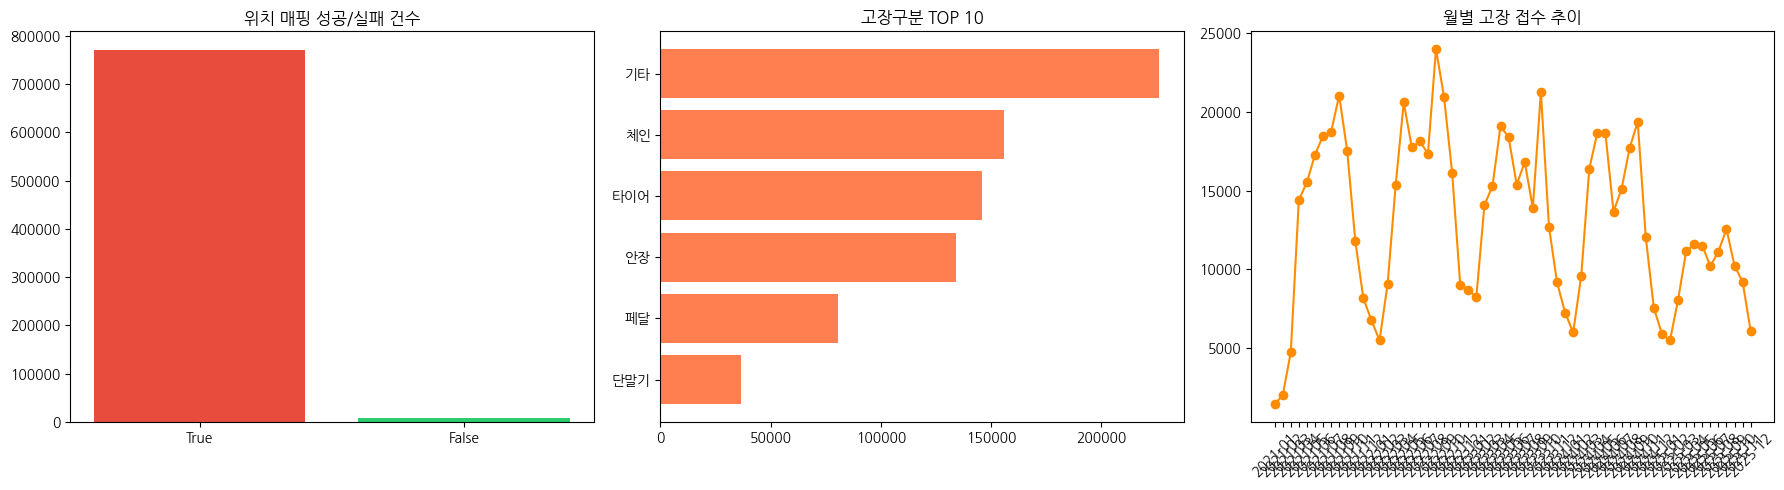

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mapped_flag = repair_station_events['추정고장대여소ID'].notna()

# 1) 위치 매핑 성공/실패
cnt = mapped_flag.value_counts(dropna=False)
axes[0].bar(cnt.index.astype(str), cnt.values, color=['#e74c3c','#2ecc71'])
axes[0].set_title('위치 매핑 성공/실패 건수')

# 2) 고장구분 TOP 10
fault_cnt = repair_station_events['고장구분'].value_counts().head(10)
axes[1].barh(fault_cnt.index.astype(str), fault_cnt.values, color='coral')
axes[1].set_title('고장구분 TOP 10')
axes[1].invert_yaxis()

# 3) 월별 고장 접수 추이
monthly = (
    repair_station_events
    .assign(year_month=pd.to_datetime(repair_station_events['등록일시']).dt.to_period('M').astype(str))
    .groupby('year_month', as_index=False)
    .size()
    .rename(columns={'size':'건수'})
)
axes[2].plot(monthly['year_month'], monthly['건수'], marker='o', color='darkorange')
axes[2].set_title('월별 고장 접수 추이')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.3 매핑 품질 요약 통계


In [18]:
mapped = repair_station_events[repair_station_events['추정고장대여소ID'].notna()]

print(f'전체 고장 건수: {len(repair_station_events):,}')
print(f'위치 매핑 성공: {len(mapped):,} ({len(mapped)/len(repair_station_events)*100:.1f}%)')
print(f'매핑된 대여소 수: {mapped["추정고장대여소ID"].nunique():,}')
print(f'매핑된 자전거 수: {mapped["자전거번호"].nunique():,}')

print("\n매핑 실패 건수:", repair_station_events['추정고장대여소ID'].isna().sum())
print("매핑 실패율(%):", round(repair_station_events['추정고장대여소ID'].isna().mean() * 100, 2))


전체 고장 건수: 779,052
위치 매핑 성공: 770,811 (98.9%)
매핑된 대여소 수: 5,665
매핑된 자전거 수: 47,504

매핑 실패 건수: 8241
매핑 실패율(%): 1.06


### 5. 매칭 결과 저장


In [19]:
# parquet 파일 저장
repair_station_events_path = os.path.join(PROCESSED_DIR, 'repair_station_events.parquet')
repair_station_events.to_parquet(repair_station_events_path, index=False)

print('저장 완료:')
print('-', repair_station_events_path)
print(f'  parquet: {os.path.getsize(repair_station_events_path)/1e6:.1f} MB')


저장 완료:
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/repair_station_events.parquet
  parquet: 12.9 MB


### 6. 대여소별 고장 핫스팟 집계


In [20]:
fault_base = repair_station_events[repair_station_events['추정고장대여소ID'].notna()].copy()
fault_base['date'] = pd.to_datetime(fault_base['등록일시']).dt.floor('D')

station_hotspot = (
    fault_base
    .groupby('추정고장대여소ID', as_index=False)
    .agg(
        고장건수=('등록일시', 'count'),
        고장자전거수=('자전거번호', 'nunique'),
        고장유형수=('고장구분', 'nunique'),
        첫고장일=('등록일시', 'min'),
        마지막고장일=('등록일시', 'max')
    )
    .sort_values('고장건수', ascending=False)
    .reset_index(drop=True)
)

station_hotspot_daily = (
    fault_base
    .groupby(['date', '추정고장대여소ID'], as_index=False)
    .agg(고장건수=('등록일시', 'count'))
    .sort_values(['date', '고장건수'], ascending=[True, False])
    .reset_index(drop=True)
)

print('station_hotspot shape:', station_hotspot.shape)
print('station_hotspot_daily shape:', station_hotspot_daily.shape)
display(station_hotspot.head(10))

station_hotspot shape: (5665, 6)
station_hotspot_daily shape: (568667, 3)


,추정고장대여소ID,고장건수,고장자전거수,고장유형수,첫고장일,마지막고장일
0,00583,1887,1552,6,2021-02-11 00:00:00,2025-12-28 18:05:02
1,04217,1546,1309,6,2022-07-01 18:28:00,2025-12-29 21:16:49
2,02102,1429,1137,6,2021-02-07 00:00:00,2025-12-28 15:22:50
3,02728,1400,1182,6,2021-04-11 00:00:00,2025-12-31 09:35:11
4,00502,1373,1146,6,2021-02-17 00:00:00,2025-12-22 08:35:13
5,01911,1247,1040,6,2021-03-04 00:00:00,2025-12-31 12:14:26
6,02715,1234,1066,6,2021-04-19 00:00:00,2025-12-30 11:14:38
7,02701,1202,1046,6,2021-02-10 00:00:00,2025-12-30 17:48:48
8,01210,1188,986,6,2021-02-08 00:00:00,2025-12-27 01:27:48
9,00272,1158,1001,6,2021-02-14 00:00:00,2025-12-31 14:47:43


### 6.1 핫스팟, 월별 추이 eda


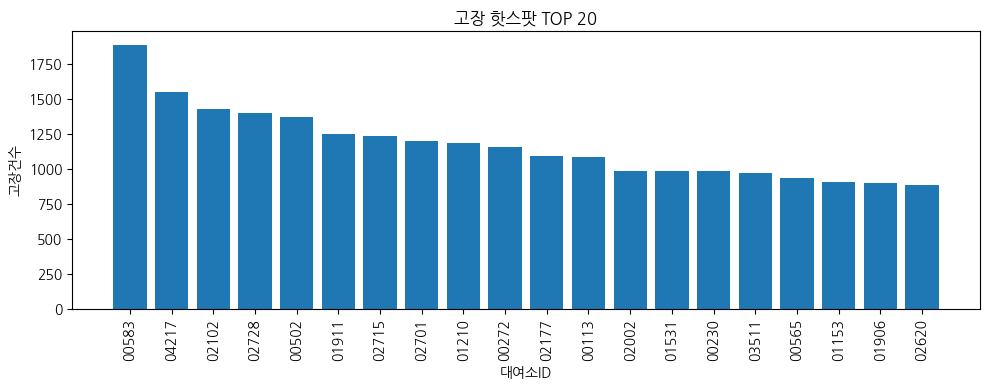

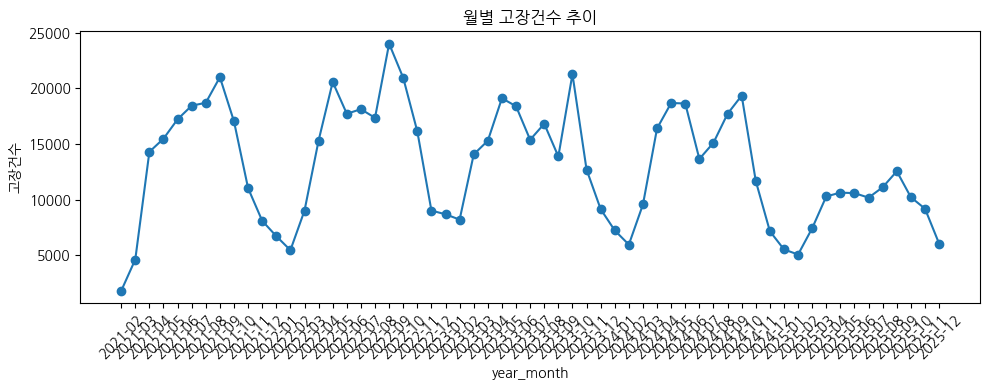

In [21]:
# Top 20 대여소
plot_df = station_hotspot.head(20)
plt.figure(figsize=(10,4))
plt.bar(plot_df['추정고장대여소ID'].astype(str), plot_df['고장건수'])
plt.title('고장 핫스팟 TOP 20')
plt.xlabel('대여소ID')
plt.ylabel('고장건수')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 월별 고장 추이
monthly = station_hotspot_daily.copy()
monthly['year_month'] = pd.to_datetime(monthly['date']).dt.to_period('M').astype(str)
monthly = monthly.groupby('year_month', as_index=False)['고장건수'].sum()

plt.figure(figsize=(10,4))
plt.plot(monthly['year_month'], monthly['고장건수'], marker='o')
plt.title('월별 고장건수 추이')
plt.xlabel('year_month')
plt.ylabel('고장건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 7. 핫스팟 집계 저장


In [22]:
station_hotspot_path = os.path.join(PROCESSED_DIR, 'station_hotspot.parquet')
station_hotspot_daily_path = os.path.join(PROCESSED_DIR, 'station_hotspot_daily.parquet')

station_hotspot.to_parquet(station_hotspot_path, index=False)
station_hotspot_daily.to_parquet(station_hotspot_daily_path, index=False)

print('저장 완료:')
print('-', station_hotspot_path)
print('-', station_hotspot_daily_path)


저장 완료:
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/station_hotspot.parquet
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/station_hotspot_daily.parquet


### 8. 위치 데이터 조인


In [28]:
loc_path_candidates = [
    os.path.join(PROCESSED_DIR, 'location_all.parquet'),
]

loc_path = pick_existing(loc_path_candidates)
if loc_path is None:
    print('location 파일 없음:', loc_path_candidates)
else:
    # 1) location 로드하고 컬럼명 정리
    loc = pd.read_parquet(loc_path).copy()
    loc.columns = [str(c).replace('\ufeff', '').strip() for c in loc.columns]

    # 2) ID 컬럼명 자동 판별
    if '대여소번호' in loc.columns:
        id_col = '대여소번호'
    elif '대여소 번호' in loc.columns:
        id_col = '대여소 번호'
    elif '추정고장대여소ID' in loc.columns:
        id_col = '추정고장대여소ID'
    else:
        raise KeyError(f"대여소 ID 컬럼을 찾지 못했습니다. 현재 컬럼: {loc.columns.tolist()}")

    # 3) 필요한 컬럼만 추출 + 표준 컬럼명
    loc = loc[[id_col, '위도', '경도']].copy()
    loc = loc.rename(columns={id_col: '추정고장대여소ID'})

    # 4) ID, 좌표 정리
    loc['추정고장대여소ID'] = (
        loc['추정고장대여소ID'].astype('string').str.strip()
        .str.replace(r'\.0$', '', regex=True)
        .str.replace(r'[^0-9]', '', regex=True)
        .replace({'': pd.NA})
        .str.zfill(5) # 대여소ID 형태 통일
    )
    loc['위도'] = pd.to_numeric(loc['위도'], errors='coerce')
    loc['경도'] = pd.to_numeric(loc['경도'], errors='coerce')

    loc = (
        loc.dropna(subset=['추정고장대여소ID', '위도', '경도'])
           .drop_duplicates(subset=['추정고장대여소ID'])
           .reset_index(drop=True)
    )

    # 5) station_hotspot ID도 통일
    station_hotspot['추정고장대여소ID'] = (
        station_hotspot['추정고장대여소ID'].astype('string').str.strip()
        .str.replace(r'\.0$', '', regex=True)
        .str.replace(r'[^0-9]', '', regex=True)
        .replace({'': pd.NA})
        .str.zfill(5)
    )

    # 6) 병합
    station_hotspot_map = station_hotspot.merge(loc, on='추정고장대여소ID', how='left')

    # 매핑률은 계산만 하고 컬럼은 저장 안 함
    mapping_ok = station_hotspot_map['위도'].notna() & station_hotspot_map['경도'].notna()

    out_path = os.path.join(PROCESSED_DIR, 'station_hotspot_map.parquet')
    station_hotspot_map.to_parquet(out_path, index=False)

    print('좌표 매핑률(%):', round(mapping_ok.mean() * 100, 4))
    print('매핑 실패 건수:', int((~mapping_ok).sum()))
    display(station_hotspot_map.head())


좌표 매핑률(%): 92.3919
매핑 실패 건수: 431


,추정고장대여소ID,고장건수,고장자전거수,고장유형수,첫고장일,마지막고장일,위도,경도
0,00583,1887,1552,6,2021-02-11 00:00:00,2025-12-28 18:05:02,37.567970,127.046890
1,04217,1546,1309,6,2022-07-01 18:28:00,2025-12-29 21:16:49,37.555576,126.896889
2,02102,1429,1137,6,2021-02-07 00:00:00,2025-12-28 15:22:50,37.484085,126.926888
3,02728,1400,1182,6,2021-04-11 00:00:00,2025-12-31 09:35:11,37.565804,126.828079
4,00502,1373,1146,6,2021-02-17 00:00:00,2025-12-22 08:35:13,37.531860,127.067192


### 8.1 지도 기반 핫스팟 eda

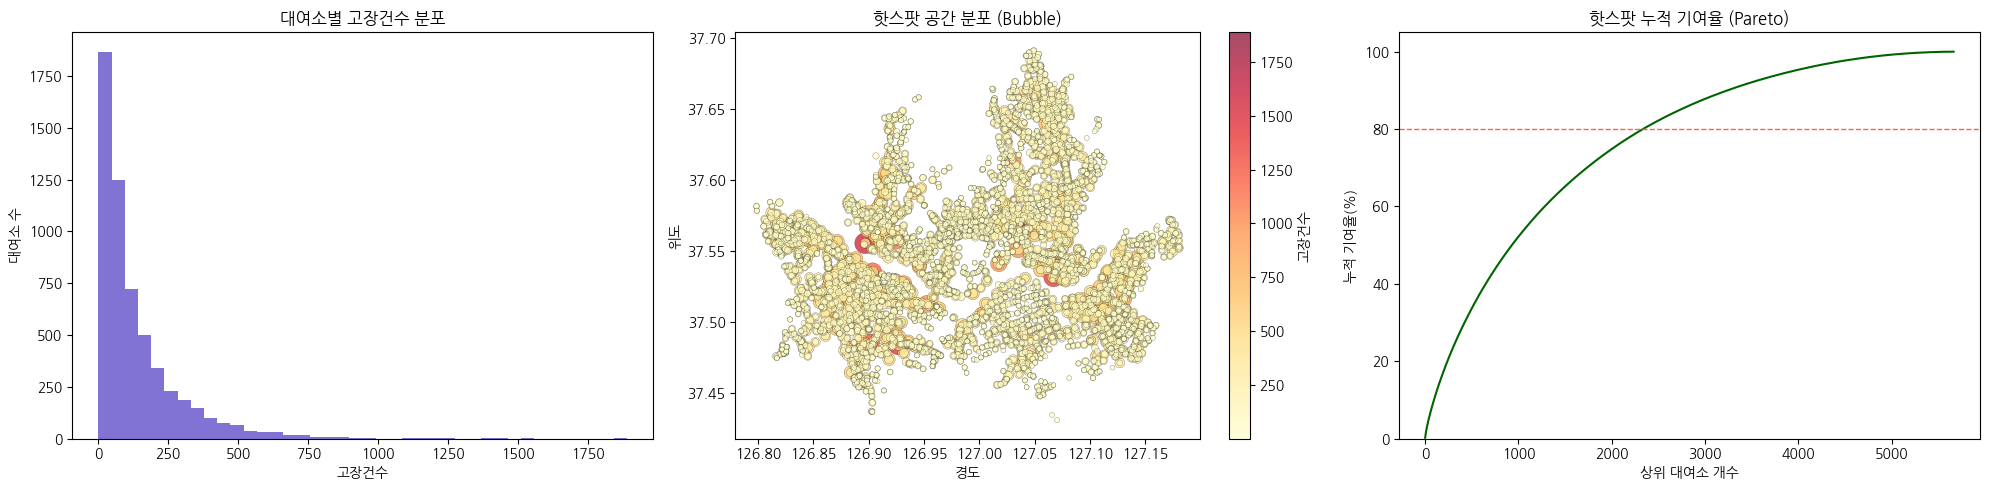

[상위 10개 핫스팟]


,추정고장대여소ID,고장건수,고장자전거수,고장유형수,위도,경도
0,00583,1887,1552,6,37.567970,127.046890
1,04217,1546,1309,6,37.555576,126.896889
2,02102,1429,1137,6,37.484085,126.926888
3,02728,1400,1182,6,37.565804,126.828079
4,00502,1373,1146,6,37.531860,127.067192
5,01911,1247,1040,6,37.484940,126.901321
6,02715,1234,1066,6,37.566925,126.827438
7,02701,1202,1046,6,37.565201,126.827316
8,01210,1188,986,6,37.513126,127.100960
9,00272,1158,1001,6,37.535339,126.903679


In [30]:
if 'station_hotspot_map' not in globals():
    print('station_hotspot_map이 없습니다. 위치 데이터 조인 셀(8)을 먼저 실행하세요.')
else:
    map_df = station_hotspot_map.copy()
    map_df = map_df.dropna(subset=['고장건수'])

    # 좌표가 있는 핫스팟만 지도 분석 대상
    map_xy = map_df.dropna(subset=['위도', '경도']).copy()

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # 1) 대여소별 고장건수 분포
    axes[0].hist(map_df['고장건수'], bins=40, color='slateblue', alpha=0.85)
    axes[0].set_title('대여소별 고장건수 분포')
    axes[0].set_xlabel('고장건수')
    axes[0].set_ylabel('대여소 수')

    # 2) 공간 분포 (위경도 산점도)
    if len(map_xy) > 0:
        size = map_xy['고장건수'].clip(lower=1).astype(float)
        size = (size / size.max()) * 260 + 12
        sc = axes[1].scatter(
            map_xy['경도'],
            map_xy['위도'],
            s=size,
            c=map_xy['고장건수'],
            cmap='YlOrRd',
            alpha=0.7,
            edgecolor='k',
            linewidth=0.2,
        )
        fig.colorbar(sc, ax=axes[1], label='고장건수')
    axes[1].set_title('핫스팟 공간 분포 (Bubble)')
    axes[1].set_xlabel('경도')
    axes[1].set_ylabel('위도')

    # 3) 누적 비율 (Pareto)
    pareto = map_df[['추정고장대여소ID', '고장건수']].sort_values('고장건수', ascending=False).reset_index(drop=True)
    pareto['누적비율'] = pareto['고장건수'].cumsum() / pareto['고장건수'].sum()
    axes[2].plot(range(1, len(pareto) + 1), pareto['누적비율'] * 100, color='darkgreen')
    axes[2].axhline(80, color='tomato', linestyle='--', linewidth=1)
    axes[2].set_title('핫스팟 누적 기여율 (Pareto)')
    axes[2].set_xlabel('상위 대여소 개수')
    axes[2].set_ylabel('누적 기여율(%)')
    axes[2].set_ylim(0, 105)

    plt.tight_layout()
    plt.show()

    print('[상위 10개 핫스팟]')
    display(map_df.sort_values('고장건수', ascending=False).head(10)[['추정고장대여소ID', '고장건수', '고장자전거수', '고장유형수', '위도', '경도']])


### 9. DuckDB 정리


In [31]:
con.close()
print('DuckDB 연결 종료')


DuckDB 연결 종료
